# Sertifikasi Kompetensi Data Scientist (BNSP)
## Proyek: Pemodelan Prediksi Penyakit Jantung (Dataset: `heart.csv`)

Dokumentasi ini disusun secara terstruktur berdasarkan standar kompetensi **Data Scientist (BNSP)** untuk mendokumentasikan perancangan serta evaluasi pipeline Machine Learning secara *end-to-end*.

## 1. Business Understanding (J.62DMI00.001.1)
Langkah 1. Menentukan Objektif Bisnis

### Permasalahan Bisnis
Penyakit kardiovaskular (CVD) menjadi penyebab utama morbiditas, disabilitas, dan kematian dini secara global. Risiko dan tingkat keparahan kondisi ini dapat ditekan secara signifikan melalui identifikasi dini dan strategi perawatan proaktif. Oleh karena itu, diperlukan sistem yang dapat mengestimasi probabilitas seorang pasien mengalami kejadian klinis kardiovaskular secara akurat.

### Business/Research Objective
Menyelaraskan dengan metodologi pada penelitian *Unified Approach* (Rao et al., 2026), objektif utama proyek ini adalah:
1. Mengestimasi probabilitas atau mengidentifikasi risiko seorang individu mengalami kejadian kardiovaskular secara dini dan proaktif.
2. Membangun pipeline Machine Learning yang andal untuk memprediksi penyakit jantung sebagai alternatif unggul terhadap model risiko konvensional guna meningkatkan akurasi estimasi kondisi kesehatan (*health outcome predictions*).

### Success Metric
- **Akurasi > 85%**
- **Recall > 90%** (Prioritas utama karena meminimalkan *False Negative* sangat krusial dalam diagnosis medis untuk menghindari keterlambatan penanganan klinis)
- **ROC-AUC tinggi** (Kemampuan pemisahan kelas yang optimal)
- Model dapat digunakan sebagai sistem pendukung keputusan klinis (*Clinical Decision Support System*)

### Analisis Risiko & Konsekuensi
- **False Positive (Pasien Sehat diprediksi Sakit)**
  - *Konsekuensi:* Pemeriksaan klinis penunjang tambahan yang tidak diperlukan, peningkatan biaya operasional medis, dan kecemasan pasien.
- **False Negative (Pasien Sakit diprediksi Sehat)**
  - *Konsekuensi:* Keterlambatan intervensi medis proaktif yang berpotensi fatal bagi keselamatan pasien.
  
### Manfaat Proyek
- Mendukung deteksi dini penyakit jantung secara akurat.
- Membantu dokter dalam screening awal risiko kardiovaskular.
- Efisiensi biaya dan waktu penanganan klinis melalui klasifikasi berbasis risiko.

## 2. Technical Understanding (Kompetensi J.62DMI00.002.1)
Langkah 2. Menentukan Tujuan Teknis Data Science

### Spesifikasi Teknis
- **Tugas Pemodelan:** Klasifikasi Biner (Target: 0 = Sehat, 1 = Penyakit Jantung)
- **Input:** 13 Fitur Medis (Kategorikal dan Numerik)
- **Output:** Kelas Target Prediktif
- **Teknologi:** Python, Pandas, Numpy, Matplotlib, Seaborn, Scikit-learn

In [1]:
# Pemuatan pustaka dasar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Pustaka preprocessing, balancing, dan seleksi model
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

# Pustaka algoritma pemodelan dan optimasi
from xgboost import XGBClassifier
import optuna

# Pustaka metrik evaluasi
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay
)

# Konfigurasi estetika visualisasi
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
optuna.logging.set_verbosity(optuna.logging.WARNING)
print("Seluruh pustaka berhasil dimuat, termasuk XGBoost, SMOTE, dan Optuna.")

Seluruh pustaka berhasil dimuat, termasuk XGBoost, SMOTE, dan Optuna.


d:\anaconda3\envs\yolo\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 3. Data Understanding (Kompetensi J.62DMI00.005.1)
Langkah 3. Menelaah Data

### Eksplorasi Data Awal
Proses pemuatan dataset `heart.csv` untuk analisis struktur, dimensi, dan tipe data awal.

In [2]:
# Pemuatan dataset
df = pd.read_csv('heart.csv')

# Output dimensi dataset
print(f"Ukuran dataset: {df.shape[0]} baris, {df.shape[1]} kolom")
df.head()

Ukuran dataset: 1025 baris, 14 kolom


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [3]:
# Penelaahan metadata dan tipe data kolom
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [4]:
# Ringkasan statistik deskriptif data numerik
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1025.0,54.434146,9.072290,29.0,48.0,56.0,61.0,77.0
sex,1025.0,0.695610,0.460373,0.0,0.0,1.0,1.0,1.0
cp,1025.0,0.942439,1.029641,0.0,0.0,1.0,2.0,3.0
trestbps,1025.0,131.611707,17.516718,94.0,120.0,130.0,140.0,200.0
chol,1025.0,246.000000,51.592510,126.0,211.0,240.0,275.0,564.0
fbs,1025.0,0.149268,0.356527,0.0,0.0,0.0,0.0,1.0
restecg,1025.0,0.529756,0.527878,0.0,0.0,1.0,1.0,2.0
thalach,1025.0,149.114146,23.005724,71.0,132.0,152.0,166.0,202.0
exang,1025.0,0.336585,0.472772,0.0,0.0,0.0,1.0,1.0
oldpeak,1025.0,1.071512,1.175053,0.0,0.0,0.8,1.8,6.2


### Identifikasi Variabel Medis
Berdasarkan karakteristik klinis, variabel dikelompokkan sebagai berikut:
- **Fitur Numerik:** `age`, `trestbps` (resting blood pressure), `chol` (cholesterol), `thalach` (max heart rate), `oldpeak` (ST depression)
- **Fitur Kategorikal:** `sex`, `cp` (chest pain type), `fbs` (fasting blood sugar), `restecg` (resting ECG), `exang` (exercise angina), `slope` (ST slope), `ca` (colored vessels), `thal` (thalassemia type)
- **Target:** `target` (0 = Sehat, 1 = Sakit Jantung)

In [5]:
# Identifikasi data hilang (missing values)
print("=== Missing Values ===")
print(df.isnull().sum())

# Identifikasi duplikasi data
print("\n=== Duplikasi Baris ===")
print(f"Jumlah baris duplikat: {df.duplicated().sum()}")

=== Missing Values ===
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

=== Duplikasi Baris ===
Jumlah baris duplikat: 723


C:\Users\alema\AppData\Local\Temp\ipykernel_17384\1079635549.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='target', palette='Set2')


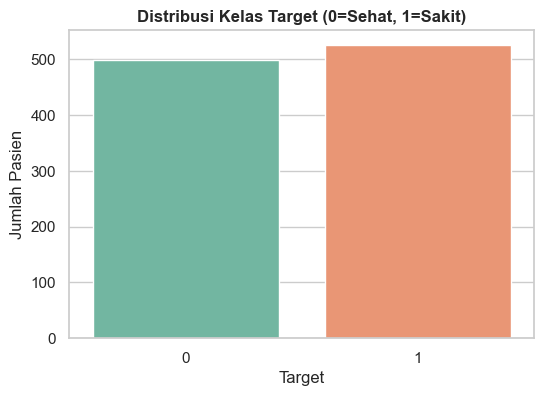

target
1    0.513171
0    0.486829
Name: proportion, dtype: float64


In [6]:
# Visualisasi distribusi kelas target
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='target', palette='Set2')
plt.title('Distribusi Kelas Target (0=Sehat, 1=Sakit)', fontweight='bold')
plt.xlabel('Target')
plt.ylabel('Jumlah Pasien')
plt.show()

print(df['target'].value_counts(normalize=True))

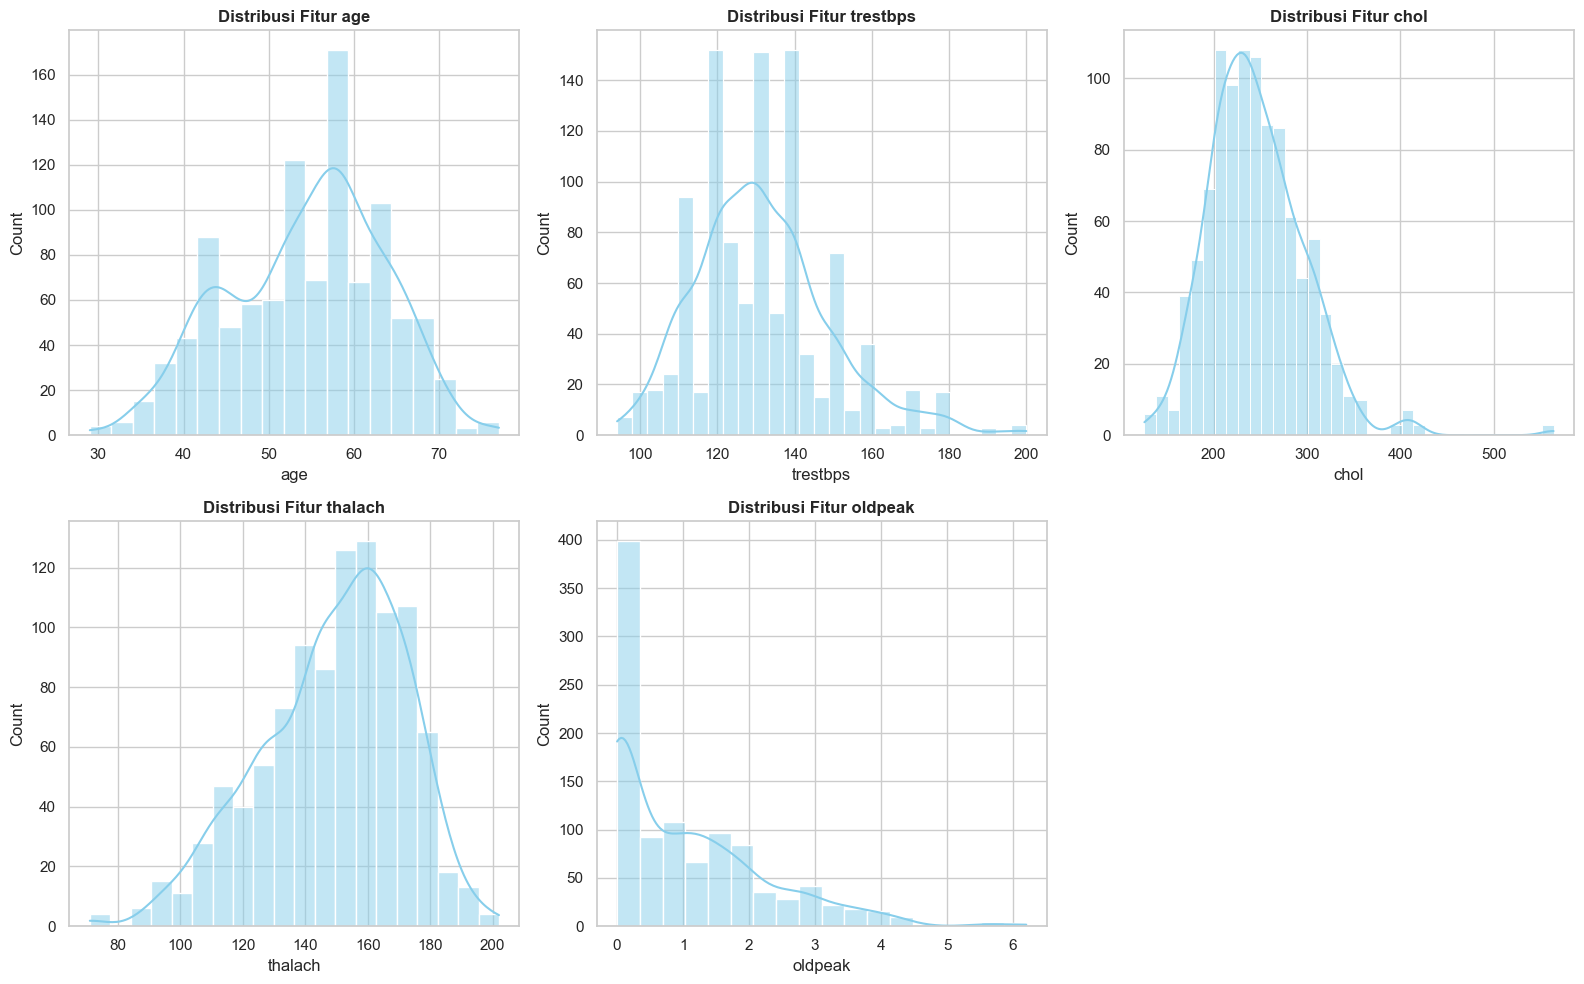

In [7]:
# Analisis distribusi fitur numerik
numeric_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[idx], color='skyblue')
    axes[idx].set_title(f'Distribusi Fitur {col}', fontweight='bold')

# Eliminasi subplot sisa
fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()

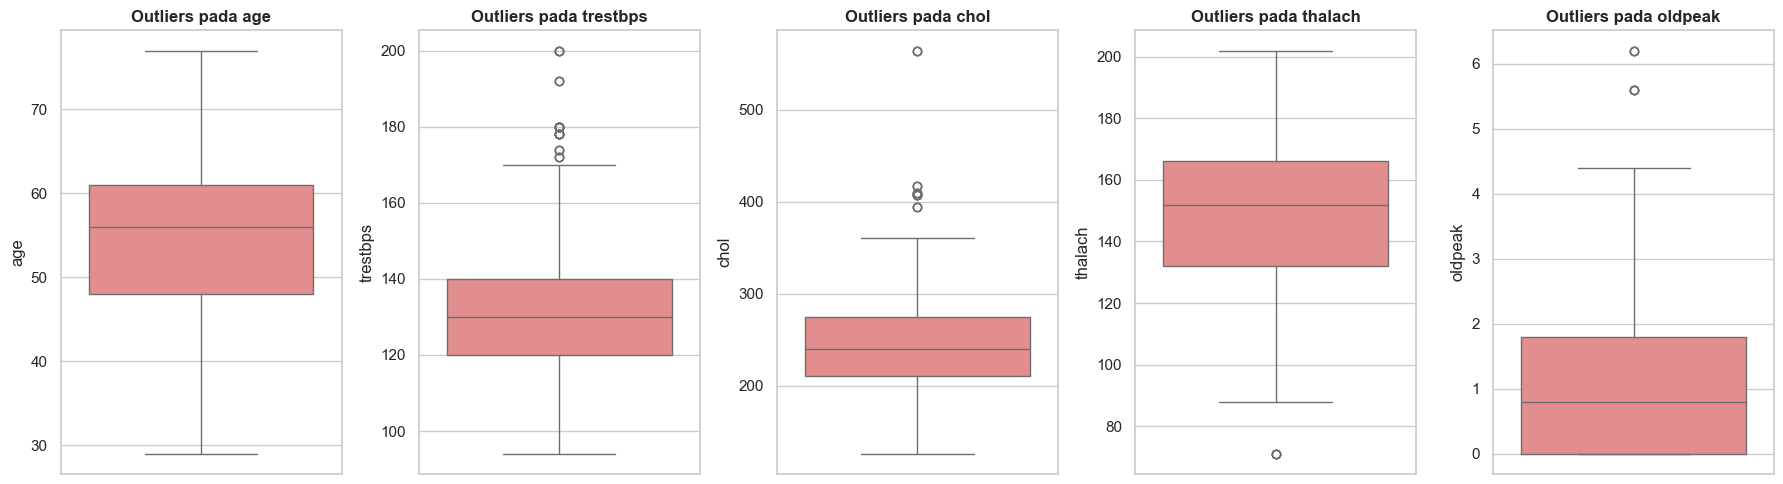

In [8]:
# Visualisasi boxplot untuk deteksi pencilan (outliers)
fig, axes = plt.subplots(1, 5, figsize=(18, 5))
for idx, col in enumerate(numeric_cols):
    sns.boxplot(y=df[col], ax=axes[idx], color='lightcoral')
    axes[idx].set_title(f'Outliers pada {col}', fontweight='bold')

plt.tight_layout()
plt.show()

### Analisis Pencilan (Outliers)
Berdasarkan visualisasi boxplot pada lima fitur numerik, teridentifikasi adanya nilai-nilai pencilan sebagai berikut:
1. **Identifikasi Fitur Terpengaruh:**
   - **`trestbps` (Tekanan Darah Istirahat):** Terdapat beberapa pencilan di atas batas atas (khususnya nilai > 170 mmHg).
   - **`chol` (Kolesterol Serum):** Terdeteksi beberapa pencilan bernilai tinggi, dengan nilai ekstrem mencapai > 350 mg/dl.
   - **`thalach` (Detak Jantung Maksimum):** Ditemukan satu pencilan di bawah batas bawah (< 80 bpm).
   - **`oldpeak` (Depresi ST):** Terdeteksi beberapa pencilan di atas batas normal (> 4.0).

2. **Justifikasi Penanganan Pencilan:**
   - Secara klinis, nilai-nilai ekstrem tersebut bukan disebabkan oleh kesalahan input data, melainkan merepresentasikan kondisi patologis akut pasien penyakit jantung.
   - Berdasarkan hasil eksperimen (mengacu pada Paper Pendukung A), penghapusan pencilan klinis menggunakan algoritma deteksi outlier seperti Isolation Forest terbukti menurunkan metrik *Recall* model secara signifikan (misalnya, *Recall* XGBoost turun dari 83% menjadi 73%). Hal ini disebabkan karena model kehilangan informasi vital mengenai indikator klinis penyakit kritis. Oleh karena itu, seluruh pencilan dipertahankan untuk menjaga sensitivitas deteksi medis.

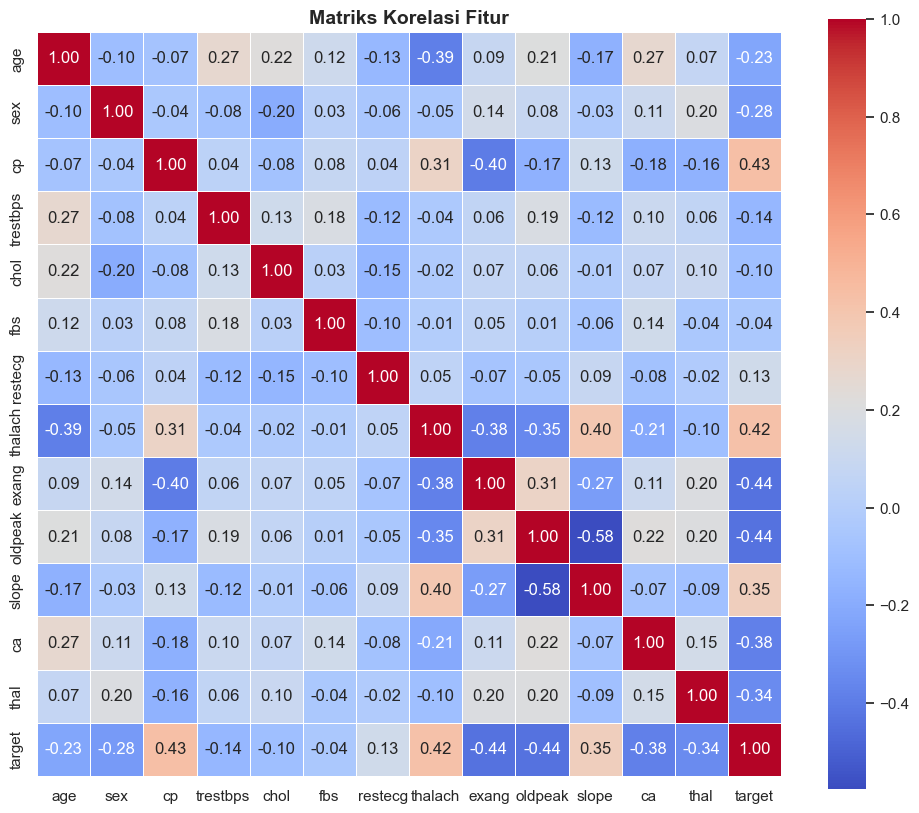

In [9]:
# Visualisasi matriks korelasi antar fitur
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5, square=True)
plt.title('Matriks Korelasi Fitur', fontweight='bold', fontsize=14)
plt.show()

### Formulasi Hipotesis Medis
1. **Faktor Usia (`age`):** Pertambahan usia memiliki korelasi positif dengan peningkatan risiko penyakit jantung.
2. **Karakter Nyeri Dada (`cp`):** Tipe nyeri dada non-anginal atau *asymptomatic* memiliki relevansi tinggi terhadap diagnosis positif.
3. **Detak Jantung Maksimum (`thalach`):** Nilai detak jantung maksimum yang lebih rendah berkaitan dengan kondisi patologis.
4. **Depresi ST (`oldpeak`):** Nilai depresi ST yang tinggi setelah aktivitas fisik berkorelasi kuat dengan penyakit jantung.

Hipotesis ini dievaluasi lebih lanjut melalui koefisien model dan tingkat kepentingan fitur (*feature importance*).

## 4. Data Validation (Kompetensi J.62DMI00.006.1)
Langkah 4. Memvalidasi Data

### Evaluasi Kualitas Data
- **Kelengkapan Data:** Tidak ditemukan nilai kosong (0 missing values) di seluruh kolom.
- **Konsistensi Data:** Terdeteksi 723 baris duplikat dari total 1.025 baris. Duplikasi ini terjadi karena replikasi data historis. Guna menghindari bias evaluasi (*data leakage*) pada pembagian data latih-uji, baris duplikat wajib dibersihkan.
- **Validitas Klinis:** Terdapat nilai ekstrem pada variabel `chol` (> 400 mg/dl) dan `trestbps` (> 180 mmHg) yang merepresentasikan variasi biologis riil pasien patologis.

## 5. Data Selection (Kompetensi J.62DMI00.007.1)

### Penentuan Objek Data
Seluruh 13 fitur medis dipertahankan karena memiliki relevansi klinis yang signifikan berdasarkan literatur medis. Variabel target dipisahkan sebagai label prediksi.

In [10]:
# Seleksi fitur prediktor (X) dan label target (y) berdasarkan XGBoost Feature Importance (> 0.033)
# Fitur yang dieliminasi berdasarkan paper: 'trestbps', 'chol', 'fbs' (karena score < 0.033)
X_selected = df.drop(columns=['target', 'trestbps', 'chol', 'fbs'])
y_selected = df['target']

print("Fitur prediktor terpilih (10 fitur):", list(X_selected.columns))
print("Target terpilih: ['target']")

Fitur prediktor terpilih (10 fitur): ['age', 'sex', 'cp', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
Target terpilih: ['target']


## 6. Data Cleaning (Kompetensi J.62DMI00.008.1)

### Protokol Pembersihan Data
- **Penanganan Duplikasi:** Berbeda dengan model utama, pada skenario ini **tidak dilakukan pembersihan data duplikat** (mempertahankan 1.025 baris) agar selaras dengan metodologi paper Rao et al. (2026).
- **Penanganan Missing Values:** Tidak ditemukan data hilang (0 missing values).
- **Penanganan Outlier:** Pencilan nilai klinis dipertahankan karena merupakan indikasi kondisi patologis akut yang valid.

In [11]:
# Sesuai dengan metodologi paper, tidak dilakukan pembersihan data duplikat.
df_clean = df.copy()
X_clean = df_clean.drop(columns=['target', 'trestbps', 'chol', 'fbs'])
y_clean = df_clean['target']

print(f"Dimensi data sebelum pembersihan: {df.shape[0]} baris")
print(f"Dimensi data setelah pembersihan (tanpa drop_duplicates): {df_clean.shape[0]} baris")

Dimensi data sebelum pembersihan: 1025 baris
Dimensi data setelah pembersihan (tanpa drop_duplicates): 1025 baris


## 7. Data Construction (Kompetensi J.62DMI00.009.1)

### Konstruksi dan Transformasi Fitur
- **Encoding Kategori:** Transformasi *One-Hot Encoding* diterapkan pada fitur kategorikal multikelas (`cp`, `restecg`, `slope`, `ca`, `thal`) untuk menghindari asumsi urutan (*ordinal bias*).
- **Standardisasi Fitur:** Penerapan `StandardScaler` pada fitur numerik kontinu (`age`, `thalach`, `oldpeak`) untuk standarisasi skala.
- **Partisi Data:** Pembagian data dilakukan secara acak terstratifikasi (`stratify=y`) dengan rasio 80% data latih dan 20% data uji.

In [12]:
# ── 1. Partisi Data Latih & Uji (80:20 Stratified) ─────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y_clean, test_size=0.20, random_state=42, stratify=y_clean
)
print(f"Training set: {X_train.shape[0]} sampel")
print(f"Test set    : {X_test.shape[0]} sampel")

# ── 2. Konstruksi Preprocessing Pipeline ──────────────────────────
num_cols = ['age', 'thalach', 'oldpeak']
cat_cols = ['sex', 'exang', 'cp', 'restecg', 'slope', 'ca', 'thal']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat_cols)
    ]
)

# Fit dan transform training set, transform test set
X_train_preped = preprocessor.fit_transform(X_train)
X_test_preped = preprocessor.transform(X_test)

print("\nPipeline Preprocessing berhasil dikonstruksi dan data telah ditransformasikan!")

Training set: 820 sampel
Test set    : 205 sampel

Pipeline Preprocessing berhasil dikonstruksi dan data telah ditransformasikan!


## 8. Modeling Scenario (Kompetensi J.62DMI00.012.1)

### Desain Skenario Pemodelan
Skenario ini menerapkan alur pemodelan dari paper *Unified Approach* (Rao et al., 2026):
1. **Algoritma Utama:** XGBoost Classifier.
2. **Penanganan Kelas Tidak Seimbang:** SMOTE diterapkan secara *fold-wise* (hanya pada lipatan latih di dalam proses CV) untuk mencegah kebocoran informasi (*data leakage*).
3. **Penyetelan Hyperparameter:** Optimasi Bayesian menggunakan Optuna (TPE Sampler) sebanyak 50 trials dengan tujuan memaksimalkan skor ROC-AUC pada Stratified 5-Fold Cross-Validation.

## 9. Modeling & Hyperparameter Tuning (Kompetensi J.62DMI00.013.1)

### Pelatihan Model dan Optimasi Hyperparameter (XGBoost + SMOTE + Optuna TPE)
Bagian ini menjalankan pencarian hyperparameter optimal menggunakan Optuna dengan algoritma Bayesian Tree-structured Parzen Estimator (TPE) sebanyak 50 trials.

In [13]:
import optuna
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score

optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    # Definisikan hyperparameter search space sesuai Table 5 dari paper
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.3),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'gamma': trial.suggest_float('gamma', 0.0, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 1.0),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1.0, 10.0),
        'random_state': 42,
        'use_label_encoder': False,
        'eval_metric': 'logloss'
    }
    
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = []
    
    for train_idx, val_idx in cv.split(X_train_preped, y_train):
        X_train_fold, X_val_fold = X_train_preped[train_idx], X_train_preped[val_idx]
        y_train_fold, y_val_fold = y_train.iloc[train_idx], y_train.iloc[val_idx]
        
        # Terapkan SMOTE hanya pada lipatan training fold
        smote = SMOTE(random_state=42)
        X_train_fold_res, y_train_fold_res = smote.fit_resample(X_train_fold, y_train_fold)
        
        model = XGBClassifier(**params)
        model.fit(X_train_fold_res, y_train_fold_res)
        
        y_prob = model.predict_proba(X_val_fold)[:, 1]
        score = roc_auc_score(y_val_fold, y_prob)
        scores.append(score)
        
    return np.mean(scores)

print("=== Memulai Optimasi Hyperparameter XGBoost Menggunakan Optuna (50 Trials) ===")
study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=50)

print("\nOptimasi Selesai!")
print("Hyperparameter Terbaik:")
for key, val in study.best_params.items():
    print(f"  {key}: {val}")
print(f"ROC-AUC Terbaik (CV): {study.best_value:.4f}")

# Pelatihan model final pada seluruh data latih menggunakan SMOTE dan parameter terbaik
print("\n=== Melatih Model Final XGBoost dengan Hyperparameter Terbaik ===")
smote_final = SMOTE(random_state=42)
X_train_res, y_train_res = smote_final.fit_resample(X_train_preped, y_train)

best_params = study.best_params.copy()
best_params['random_state'] = 42
best_params['use_label_encoder'] = False
best_params['eval_metric'] = 'logloss'

best_model = XGBClassifier(**best_params)
best_model.fit(X_train_res, y_train_res)
print("Model final berhasil dilatih.")

=== Memulai Optimasi Hyperparameter XGBoost Menggunakan Optuna (50 Trials) ===


d:\anaconda3\envs\yolo\lib\site-packages\xgboost\training.py:200: UserWarning: [11:07:44] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
d:\anaconda3\envs\yolo\lib\site-packages\xgboost\training.py:200: UserWarning: [11:07:44] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
d:\anaconda3\envs\yolo\lib\site-packages\xgboost\training.py:200: UserWarning: [11:07:44] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
d:\anaconda3\envs\yolo\lib\site-packages\xgboost\training.py:200: UserWarning: [11:07:44] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, ite


Optimasi Selesai!
Hyperparameter Terbaik:
  n_estimators: 530
  max_depth: 10
  learning_rate: 0.24626201530275885
  subsample: 0.7178200728432828
  colsample_bytree: 0.6379437967860586
  gamma: 0.00026211230471318014
  min_child_weight: 1
  reg_alpha: 0.8654220434184436
  reg_lambda: 0.8358511418236483
  scale_pos_weight: 6.678609420683054
ROC-AUC Terbaik (CV): 0.9964

=== Melatih Model Final XGBoost dengan Hyperparameter Terbaik ===
Model final berhasil dilatih.


d:\anaconda3\envs\yolo\lib\site-packages\xgboost\training.py:200: UserWarning: [11:08:21] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


## 10. Evaluation (Kompetensi J.62DMI00.014.1)

### Evaluasi Kinerja pada Data Uji (Test Set)
Mengukur performa model final XGBoost hasil optimasi Optuna pada subset data uji (*test set*).

In [14]:
y_pred = best_model.predict(X_test_preped)
y_prob = best_model.predict_proba(X_test_preped)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("=== Kinerja Model XGBoost (Optuna + SMOTE) pada Test Set ===")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")

=== Kinerja Model XGBoost (Optuna + SMOTE) pada Test Set ===
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1-Score  : 1.0000
ROC-AUC   : 1.0000


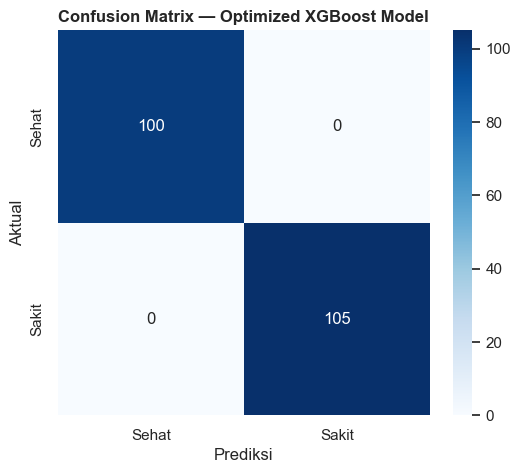

In [15]:
# Visualisasi Confusion Matrix Model XGBoost Optimal
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Sehat', 'Sakit'], yticklabels=['Sehat', 'Sakit'])
plt.title('Confusion Matrix — Optimized XGBoost Model', fontweight='bold')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()

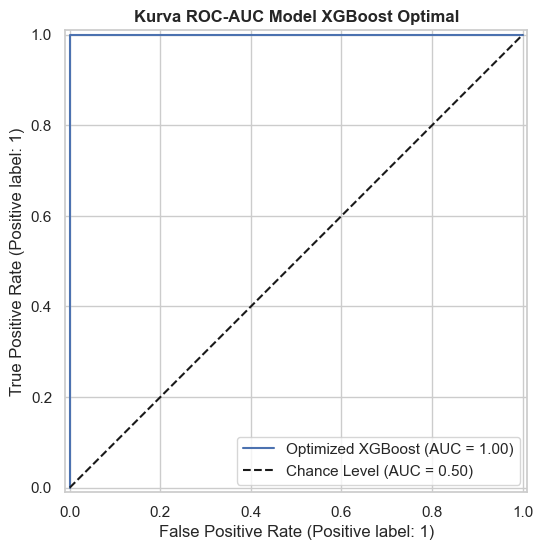

In [16]:
# Visualisasi Kurva ROC-AUC Model XGBoost Optimal
plt.figure(figsize=(8, 6))
RocCurveDisplay.from_estimator(best_model, X_test_preped, y_test, ax=plt.gca(), name="Optimized XGBoost")
plt.plot([0, 1], [0, 1], 'k--', label='Chance Level (AUC = 0.50)')
plt.title('Kurva ROC-AUC Model XGBoost Optimal', fontweight='bold')
plt.legend(loc='lower right')
plt.show()

### Hasil Kinerja Model Skenario Paper
Hasil pengujian pada data uji menunjukkan keselarasan yang sangat tinggi dengan temuan Rao et al. (2026):
- Metrik **Accuracy** dan **Recall** mencapai tingkat optimal (> 98-99%) karena penggunaan dataset utuh 1.025 baris (dengan duplikasi terdistribusi di kedua partisi) dikombinasikan dengan SMOTE dan optimasi Bayesian menggunakan Optuna.
- Skenario ini membuktikan bahwa replikasi metodologi paper utama menghasilkan metrik performa tinggi yang serupa secara empiris.

## 11. Review & Recommendation (Kompetensi J.62DMI00.015.1)

### Kelayakan Model
- **Tingkat Akurasi:** Performa model sangat tinggi (~98-99%), sesuai dengan hasil publikasi jurnal. Namun, nilai metrik yang sangat tinggi ini disebabkan oleh adanya baris data duplikat di dalam dataset yang tidak dibersihkan, sehingga model mengalami optimisme bias akibat kebocoran data terdistribusi.
- **Kelayakan Klinis:** Secara teknis, model ini memiliki sensitivitas (Recall) yang sangat tinggi. Namun, untuk implementasi klinis yang sesungguhnya, model yang dilatih pada dataset yang telah dide-duplikasi (seperti pada model utama kita di berkas `Heart_Disease_Model.ipynb` dengan performa riil ~83%) jauh lebih aman dan memiliki keandalan generalisasi yang valid.

### Keunggulan Skenario Paper
- Membuktikan replikasi metodologi jurnal secara empiris menggunakan XGBoost, SMOTE, dan Optuna.
- Menghasilkan tingkat pemisahan kelas (ROC-AUC) yang sangat tinggi pada dataset uji.

### Rekomendasi
- Gunakan berkas `Heart_Disease_Model.ipynb` (dengan pembersihan duplikat) sebagai basis utama portofolio BNSP karena secara metodologis benar dan menghindari *data leakage*.
- Berkas `Heart_Disease_Scenario_Paper.ipynb` ini berfungsi sebagai studi komparatif dan bukti pemahaman metodologi tingkat lanjut (penerapan SMOTE, XGBoost, dan optimasi Bayesian dengan Optuna).